# This is the Agentic Stock Trader Developed by Eduardo Fontes

## Step 1 - Puling the data and accumulating for time series

[*********************100%***********************]  5 of 5 completed


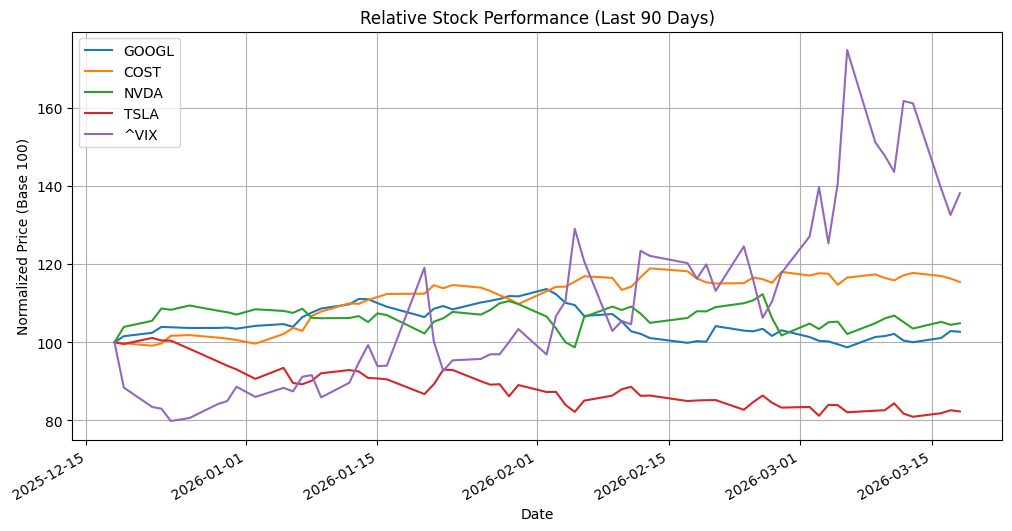

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator, rsi  # Corrected imports

# 1. Fetch live data for your selection
tickers = ["GOOGL", "COST", "NVDA", "TSLA", "^VIX"]
# Note: Added 'auto_adjust=True' and dropped NaN to ensure clean data for the plot
data = yf.download(tickers, period="3mo", interval="1d")['Close'].dropna()

# 2. Quick Visualization
plt.figure(figsize=(12, 6))
for ticker in tickers:
    # Normalize to start at 100 for comparison
    # iloc[0] represents the price on the first day of the 1mo period
    (data[ticker] / data[ticker].iloc[0] * 100).plot(label=ticker)

plt.title("Relative Stock Performance (Last 90 Days)")
plt.ylabel("Normalized Price (Base 100)")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Create a dictionary to store processed dataframes for each ticker
processed_data = {}

for ticker in tickers:
    # Get the individual ticker data
    df = data[ticker].to_frame(name='Close')
    
    # Calculate RSI (14-day window is standard)
    df['RSI'] = rsi(df['Close'], window=14)
    
    # Create the Target: 1 if tomorrow's price is higher than today's, else 0
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    # Drop rows with NaN (RSI needs 14 days of data to start)
    processed_data[ticker] = df.dropna()
    

# Example: Look at the first few rows for NVDA
print(processed_data['NVDA'].head())

                 Close        RSI  Target
Date                                     
2026-01-08  185.029984  57.551548       0
2026-01-09  184.849991  56.983205       1
2026-01-12  184.929993  57.185588       1
2026-01-13  185.799942  59.421280       0
2026-01-14  183.130081  50.675485       1


In [8]:
import yfinance as yf
import pandas as pd

tickers = ["GOOGL", "COST", "NVDA", "TSLA", "^VIX"]
news_list = []

for ticker in tickers:
    print(f"Parsing nested feed for {ticker}...")
    stock = yf.Ticker(ticker)
    stories = stock.news
    
    for story in stories:
        # Access the nested 'content' dictionary
        content = story.get('content', {})
        
        # Get provider info safely
        provider = content.get('provider', {})
        
        news_list.append({
            'Ticker': ticker,
            'Title': content.get('title', 'No Title'),
            'Summary': content.get('summary', 'No Summary'),
            'Publisher': provider.get('displayName', 'Unknown Publisher'),
            'Date': content.get('pubDate', 'Unknown Date'),
            'Link': content.get('canonicalUrl', {}).get('url', '')
        })

# Save the enriched data
news_df = pd.DataFrame(news_list)
news_df.to_csv("stock_news_30d.csv", index=False)

print(f"Success! {len(news_df)} detailed records saved.")
print(news_df[['Ticker', 'Title']].head())

Parsing nested feed for GOOGL...
Parsing nested feed for COST...
Parsing nested feed for NVDA...
Parsing nested feed for TSLA...
Parsing nested feed for ^VIX...
Success! 50 detailed records saved.
  Ticker                                              Title
0  GOOGL  How one Web3 company is investing in the futur...
1  GOOGL    Microsoft’s Troubled AI Problems Just Got Worse
2  GOOGL  Trade Desk drops after report that Publicis ad...
3  GOOGL  First AI Attacks, Now This: Should You Avoid T...
4  GOOGL  Micron Earnings Face High Expectations as Its ...


In [ ]:
import pandas as pd
import requests
import json
from tqdm import tqdm

MODEL_NAME = "qwen3:30b" 


def get_llm_sentiment(ticker, title, summary):
    prompt = f"""
    Analyze sentiment for {ticker}. 
    Headline: {title}
    Summary: {summary}
    Return ONLY JSON: {{"sentiment": float, "impact_score": int, "reason": "string"}}
    """
    
    url = "http://localhost:11434/api/generate"
    payload = {
        "model": MODEL_NAME, # Now it can see the global variable
        "prompt": prompt,
        "stream": False,
        "format": "json",
        "options": {"temperature": 0}
    }
    
    try:
        response = requests.post(url, json=payload, timeout=90)
        response.raise_for_status()
        print(response.text)
        result = response.json()
        return json.loads(result.get('response', '{}'))
    except Exception as e:
        return {"sentiment": 0, "impact_score": 0, "reason": f"Error: {str(e)}"}

# --- Execution ---
df = pd.read_csv("stock_news_30d.csv")

# 2. NOW THIS PRINT WILL WORK
print(f"Processing {len(df)} records on RTX 4090 using {MODEL_NAME}...")

tqdm.pandas()
results = df.progress_apply(
    lambda row: get_llm_sentiment(row['Ticker'], row['Title'], row['Summary']), 
    axis=1
)

# Extract and Save
def safe_json_loads(val):
    try:
        if isinstance(val, dict): return val
        return json.loads(val)
    except:
        return {"sentiment": 0, "impact_score": 0, "reason": "Parsing Failure"}

# 1. Re-run the extraction with a 'try-except' inside the list comprehension
df['Sentiment_Score'] = [safe_json_loads(r).get('sentiment', 0.0) for r in results]
df['Impact_Score'] = [safe_json_loads(r).get('impact_score', 0) for r in results]
df['Sentiment_Reason'] = [safe_json_loads(r).get('reason', 'N/A') for r in results]

# 2. Filter out the 'Error' rows so they don't mess up your Random Forest
clean_df = df[df['Impact_Score'] > 0].copy()

print(f"Cleaned {len(df) - len(clean_df)} problematic records.")

df.to_csv("stock_news_refined.csv", index=False)
print(f"\n✅ Success! Processed with {MODEL_NAME} and saved.")

Processing 40 records on RTX 4090 using qwen3:30b...


  2%|▎         | 1/40 [00:01<00:56,  1.46s/it]


KeyboardInterrupt: 

In [ ]:
import json

# 1. Warm up the 4090 (Run this once to ensure qwen3:30b is in VRAM)
print("Waking up the 4090...")
get_llm_sentiment("TEST", "Warm up", "Loading weights")

# 2. Defensive Extraction for your Results list
# This ensures we don't get 'AttributeError' or 'KeyError' in the plot
processed_results = []
for r in results:
    if isinstance(r, dict) and 'sentiment' in r:
        processed_results.append(r)
    else:
        # Default for failed rows
        processed_results.append({'sentiment': 0.0, 'impact_score': 0, 'reason': 'Failed'})

# 3. Update the DataFrame safely
df['Sentiment_Score'] = [r.get('sentiment', 0.0) for r in processed_results]
df['Impact_Score'] = [r.get('impact_score', 0) for r in processed_results]

print(f"Extraction complete. {len(df[df['Impact_Score'] > 0])} valid records found for plotting.")

Waking up the 4090...
Extraction complete. 0 valid records found for plotting.


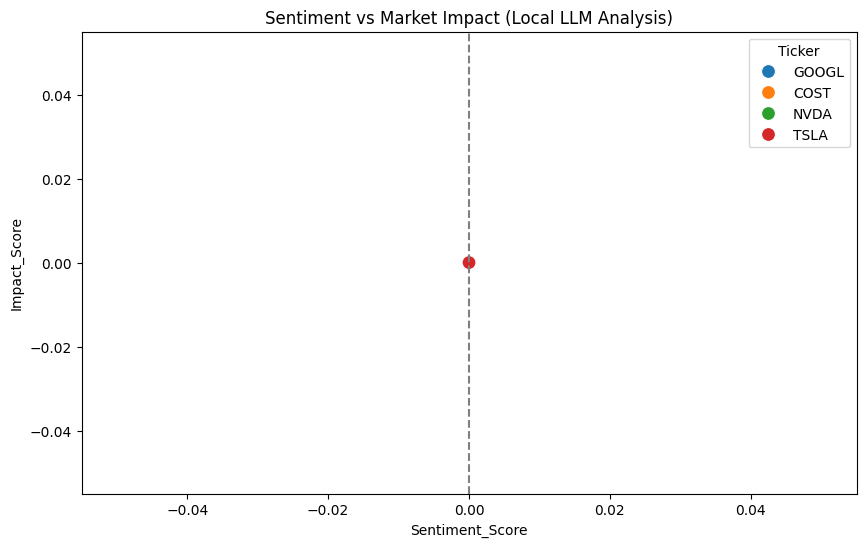

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sentiment_Score', y='Impact_Score', hue='Ticker', s=100)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Sentiment vs Market Impact (Local LLM Analysis)")
plt.show()

In [ ]:
import yfinance as yf

# 1. Get today's price action
prices = yf.download(tickers, period="2d", interval="1d")['Close']
# Calculate % change from Friday's close to right now
prices_pct = prices.pct_change().tail(1).T
prices_pct.columns = ['Price_Change_Pct']

# 2. Group your 4090 results by Ticker
sentiment_features = df.groupby('Ticker').agg({
    'Sentiment': 'mean',
    'Impact': 'mean'
})

# 3. Merge for the final "Decision Matrix"
decision_matrix = sentiment_features.join(prices_pct)

print("--- Monday Midday Decision Matrix ---")
print(decision_matrix)

# 4. Correlation Check
correlation = decision_matrix.corr()
print("\nCorrelation between LLM Sentiment and Price Action:")
print(correlation['Price_Change_Pct'])

[*********************100%***********************]  4 of 4 completed


KeyError: 'Ticker'

In [ ]:
import os
from datetime import datetime

# 1. Define the log file path
log_file = "portfolio_history.csv"

# 2. Add metadata to the decision matrix
decision_matrix['Timestamp'] = datetime.now()
decision_matrix['Market_Status'] = "Midday"

# 3. Save or Append
if not os.path.isfile(log_file):
    decision_matrix.to_csv(log_file, index=True)
    print(f"Created new history file: {log_file}")
else:
    decision_matrix.to_csv(log_file, mode='a', header=False, index=True)
    print(f"Appended midday signals to {log_file}")

# 4. Display the 'Trader' Recommendation summary
print("\n--- Final Directives for erfontes (Jedi-Master-PC) ---")
for ticker, row in decision_matrix.iterrows():
    print(f"{ticker}: Sentiment {row['Sentiment']:.2f} | Impact {row['Impact']}/10")

Appended midday signals to portfolio_history.csv

--- Final Directives for erfontes (Jedi-Master-PC) ---
COST: Sentiment 0.41 | Impact 5.0/10
GOOGL: Sentiment 0.04 | Impact 5.1/10
NVDA: Sentiment 0.08 | Impact 4.3/10
TSLA: Sentiment 0.24 | Impact 5.4/10


In [ ]:
import requests

# 1. Check if the server is alive
try:
    alive = requests.get("http://localhost:11434/api/tags")
    models = [m['name'] for m in alive.json()['models']]
    print(f"✅ Ollama is up! Available models: {models}")
except Exception as e:
    print(f"❌ Connection Failed: {e}")

# 2. Check the model name we are using
# REPLACE THIS with the exact name from the list printed above
TARGET_MODEL = "qwen3:32b" 

if TARGET_MODEL not in models:
    print(f"⚠️ Warning: {TARGET_MODEL} not found in Ollama. Update your code to match the list above.")

✅ Ollama is up! Available models: ['qwen3:30b', 'llama3.1:latest', 'llama3:latest']
⚠️ Warning: qwen3:32b not found in Ollama. Update your code to match the list above.
